# Chapter 13: Learning to Choose: Training an Agent from Trajectories

A controller learns to choose the action its verifier rewards most. Training reward rises, and the result looks successful. Yet the verifier might favor a shortcut that seldom completes the external task. Optimization can amplify that mismatch rather than correct it.

This notebook trains an actual finite softmax policy from sampled actions. It keeps verifier reward and external success probability in separate vectors and uses a separate random stream for evaluation. Repeated seeds expose stochastic learning variation. The changed case aligns the reward ranking with the task ranking. The transfer case changes terminal shaping, showing how a seemingly helpful addition can alter the objective itself.

**Outcome:** Train a seeded softmax policy with REINFORCE and evaluate a separate success predicate.

- Inspect the declared input contract
- Predict the hand-checkable case
- Run the shared computation
- Change the critical assumption
- Apply the method to the transfer data

**Guided route:** Run the worked calculation, inspect its figure, change the stated assumption, and try the transfer case. Read the explanations beside each result before opening the answers.

**Deeper route:** First read the mathematics and canonical equation reference. Audit the input contract, predict the changed result, then inspect the shared chapter implementation and solve the questions independently. Both routes use the same calculations and preserve the equations.

## Technical Requirements

Python 3.11 or later, the complete laboratory folder, and the notebook dependencies listed in `requirements-notebooks.txt` (the launcher's **Install notebook tools** choice installs them; see START-HERE). Standard-library chapter commands also support Python 3.10. No API key, model account or network call is used by this experiment.

Prior knowledge:

- Python lists and dictionaries
- The mapped chapter and its notation

## The question and its mathematics

For logits theta_i, softmax gives pi_i=exp(theta_i)/sum_j exp(theta_j). REINFORCE uses the score gradient d log pi_A/d theta_i=1{i=A}-pi_i. The update here is theta_i <- theta_i+alpha(R_A-b)(1{i=A}-pi_i), where b is the current expected shaped reward. A baseline independent of the sampled action's randomness reduces variability without changing the expected score-gradient direction.

This one-step experiment uses deterministic verifier reward after action selection. Shaped reward adds gamma Phi(terminal) with initial potential zero. In a properly terminated episodic construction, zero terminal potential preserves the original objective. A nonzero action-dependent terminal potential can change rankings, so the report exposes that condition.

Expected verifier reward is sum_i pi_i r_i; expected external success is sum_i pi_i p_i. They are different functions of the same policy. Independent evaluation draws actions and Bernoulli success from a fresh seeded stream. Its empirical rate has finite-sample noise and is not identical to the known constructed expectation.

## A calculation you can run

Supply aligned verifier rewards, external success probabilities, and terminal potentials. Declare episodes, learning rate, discount, seeds, and evaluation count. Each seed begins with equal logits. Stable softmax subtracts the maximum logit before exponentiation, avoiding avoidable overflow.

At every training episode, the code samples one action, computes its centered shaped reward, updates all logits, and records expected unshaped verifier reward. After training, it reports the policy, expected external success, and a separate empirical evaluation rate. Curves are labeled by seed. Compare their direction with the external metrics rather than calling any upward reward curve task improvement. The changed reward vector is the only altered mechanism.

The next cell finds the bundle and imports the same computation used by the chapter skill. It does not change your system Python.

In [1]:
from pathlib import Path
import sys, json
LAB_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "lab-manifest.json").is_file()), None)
if LAB_ROOT is None:
    raise RuntimeError("Open this notebook from the complete extracted laboratory folder.")
sys.path.insert(0, str(LAB_ROOT / "src"))
from math_ai_agents.core import analyze, report_text
from math_ai_agents.plotting import figure_svg
from IPython.display import SVG, display


Set the declared inputs below. These are constructed teaching values, not measurements from a production agent. Change a value only after predicting what it should change.

In [2]:
chapter = 13
inputs = {'rewards': [1, 2],
 'success_probabilities': [0.9, 0.2],
 'terminal_potentials': [0, 0],
 'episodes': 120,
 'seeds': [3, 11],
 'learning_rate': 0.08,
 'discount': 1,
 'evaluation_runs': 200}
report = analyze(chapter, inputs)
# This input was explicitly taken from the teaching fixture.
report['evidence_kind'] = 'constructed teaching example'
print(report_text(report))

Chapter 13: finite-policy-learning
Does optimizing the verifier reward improve the external task?
Evidence: constructed teaching example

Calculated quantities:
{
  "runs": [
    {
      "seed": 3,
      "policy": [
        0.05660390942,
        0.9433960906
      ],
      "expected_training_reward": 1.943396091,
      "expected_shaped_reward": 1.943396091,
      "expected_external_success": 0.2396227366,
      "independent_evaluation_rate": 0.245,
      "evaluation_n": 200
    },
    {
      "seed": 11,
      "policy": [
        0.08134967477,
        0.9186503252
      ],
      "expected_training_reward": 1.918650325,
      "expected_shaped_reward": 1.918650325,
      "expected_external_success": 0.2569447723,
      "independent_evaluation_rate": 0.3,
      "evaluation_n": 200
    }
  ],
  "policy_invariant_shaping_condition": true,
  "verifier_optimal_action": 1,
  "shaped_rewards": [
    1.0,
    2.0
  ],
  "shaped_optimal_action": 1,
  "training_objective_conflicts_with_task": tr

Initially the default policy is [0.5,0.5], with verifier reward 1.5 and external success 0.55. The verifier prefers action 1 with reward 2, while the task prefers action 0 with success probability 0.9. Learning toward the verifier can therefore raise reward while lowering expected task success.

The changed reward vector [2,1] aligns both rankings. Reward-directed learning can now increase external success. Exact final policies differ by seed, so the hand check focuses on rankings, normalization, and expected metrics rather than a selected flattering run. Separate evaluation remains finite evidence even when the constructed expectation is known.

The plot below uses the calculated quantities. Read each panel's units before comparing its values.

Matplotlib is building the font cache; this may take a moment.


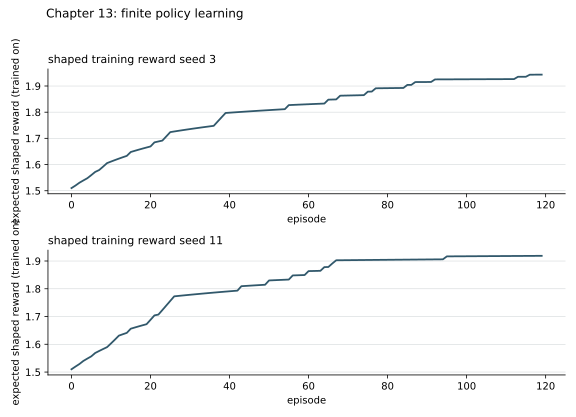

In [3]:
display(SVG(figure_svg(report)))

**Figure 13.L1:** Calculated chapter experiment. Each panel labels its input and output units; interpret it under the assumptions printed in the report.

## Change the assumption

Verifier agreement is not an independent correctness guarantee. If reward and external success share the same mistaken criterion, evaluation can repeat the training error. This experiment keeps them separate precisely to make that mismatch inspectable.

Reward shaping is another boundary. Potential differences can preserve optimal behavior under their assumptions, but arbitrary terminal bonuses do not inherit that guarantee. The transfer case assigns potential 2 to the zero-reward action, giving it shaped reward 2 against the other action's reward 1. Training can then favor external failure.

This runtime trains only a one-step finite policy. It does not train a language model or claim convergence of a general agent. Multi-step return estimation, function approximation, safety constraints, and deployment shifts need additional models and evidence. Record all seeds and evaluation counts rather than presenting one policy snapshot as a universal result.

Chapter 13: finite-policy-learning
Does optimizing the verifier reward improve the external task?
Evidence: constructed changed-assumption example

Calculated quantities:
{
  "runs": [
    {
      "seed": 3,
      "policy": [
        0.956006131,
        0.04399386903
      ],
      "expected_training_reward": 1.956006131,
      "expected_shaped_reward": 1.956006131,
      "expected_external_success": 0.8692042917,
      "independent_evaluation_rate": 0.885,
      "evaluation_n": 200
    },
    {
      "seed": 11,
      "policy": [
        0.9454970276,
        0.0545029724
      ],
      "expected_training_reward": 1.945497028,
      "expected_shaped_reward": 1.945497028,
      "expected_external_success": 0.8618479193,
      "independent_evaluation_rate": 0.88,
      "evaluation_n": 200
    }
  ],
  "policy_invariant_shaping_condition": true,
  "verifier_optimal_action": 0,
  "shaped_rewards": [
    2.0,
    1.0
  ],
  "shaped_optimal_action": 0,
  "training_objective_conflicts_with_

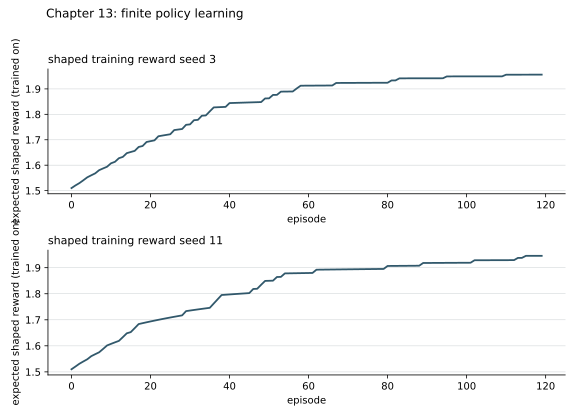

In [4]:
changed_inputs = {'rewards': [2, 1],
 'success_probabilities': [0.9, 0.2],
 'terminal_potentials': [0, 0],
 'episodes': 120,
 'seeds': [3, 11],
 'learning_rate': 0.08,
 'discount': 1,
 'evaluation_runs': 200}
changed = analyze(chapter, changed_inputs)
changed['evidence_kind'] = 'constructed changed-assumption example'
print(report_text(changed))
display(SVG(figure_svg(changed)))

**Figure 13.L2:** The changed-assumption result. Compare the printed quantities and the stated assumptions with the first run. A different input need not imply a causal effect in a deployed agent.

## Try a new case

In the transfer case, action 0 has unshaped reward 0 and external success 0, but terminal potential 2 makes its shaped reward 2. Action 1 has reward 1 and success 1. The shaping condition is false, so the learner is trained on shaped rewards [2, 1] while the external task prefers action 1. Read the fields by name: verifier_optimal_action ranks the unshaped rewards and still says action 1, but shaped_optimal_action ranks the rewards the optimizer actually uses and says action 0, and training_objective_conflicts_with_task is true. expected_training_reward is the unshaped expectation, while expected_shaped_reward is the quantity the plotted curves track and the one that rises. Predict that conflict before inspecting the seeded curves.

For a compatible local experiment, use a finite declared action set and an independently defined success predicate. Keep evaluation evidence outside reward adaptation. If the real question concerns a trajectory policy, treat this laboratory as a mechanics check and specify the missing return, state, and evaluation contracts before claiming broader learning capability.

In [5]:
transfer_inputs = {'rewards': [0, 1],
 'success_probabilities': [0, 1],
 'terminal_potentials': [2, 0],
 'episodes': 100,
 'seeds': [7, 17],
 'learning_rate': 0.1,
 'discount': 1,
 'evaluation_runs': 100}
transfer = analyze(chapter, transfer_inputs)
transfer['evidence_kind'] = 'constructed transfer example'
print(report_text(transfer))

Chapter 13: finite-policy-learning
Does optimizing the verifier reward improve the external task?
Evidence: constructed transfer example

Calculated quantities:
{
  "runs": [
    {
      "seed": 7,
      "policy": [
        0.922620852,
        0.077379148
      ],
      "expected_training_reward": 0.077379148,
      "expected_shaped_reward": 1.922620852,
      "expected_external_success": 0.077379148,
      "independent_evaluation_rate": 0.09,
      "evaluation_n": 100
    },
    {
      "seed": 17,
      "policy": [
        0.9433388176,
        0.05666118237
      ],
      "expected_training_reward": 0.05666118237,
      "expected_shaped_reward": 1.943338818,
      "expected_external_success": 0.05666118237,
      "independent_evaluation_rate": 0.09,
      "evaluation_n": 100
    }
  ],
  "policy_invariant_shaping_condition": false,
  "verifier_optimal_action": 1,
  "shaped_rewards": [
    2.0,
    1.0
  ],
  "shaped_optimal_action": 0,
  "training_objective_conflicts_with_task": tr

## Apply the method to your inputs

The example file below has the exact input shape the method accepts. Copy it to a new file, replace its values, then point `reader_file` at your copy. Run the cell again. Supplied inputs retain their stated provenance; the program cannot establish that they are representative observations.

- **rewards:** Finite verifier reward per one-step action.
- **success_probabilities:** External success chance per action in [0,1].
- **terminal_potentials:** Potential value of each terminal action outcome; zero is the episodic invariant condition.
- **episodes:** Bounded training sample count 1..10000.
- **seeds:** Nonempty integer seed list.
- **learning_rate:** Logit step size in [0,1].
- **discount:** Gamma in [0,1].
- **evaluation_runs:** Positive separate evaluation count.

In [6]:
reader_file = LAB_ROOT / 'data/examples/ch13.json'
reader_inputs = json.loads(reader_file.read_text())
reader_report = analyze(chapter, reader_inputs)
print(report_text(reader_report))

Chapter 13: finite-policy-learning
Does optimizing the verifier reward improve the external task?
Evidence: supplied local inputs; provenance not independently verified

Calculated quantities:
{
  "runs": [
    {
      "seed": 7,
      "policy": [
        0.922620852,
        0.077379148
      ],
      "expected_training_reward": 0.077379148,
      "expected_shaped_reward": 1.922620852,
      "expected_external_success": 0.077379148,
      "independent_evaluation_rate": 0.09,
      "evaluation_n": 100
    },
    {
      "seed": 17,
      "policy": [
        0.9433388176,
        0.05666118237
      ],
      "expected_training_reward": 0.05666118237,
      "expected_shaped_reward": 1.943338818,
      "expected_external_success": 0.05666118237,
      "independent_evaluation_rate": 0.09,
      "evaluation_n": 100
    }
  ],
  "policy_invariant_shaping_condition": false,
  "verifier_optimal_action": 1,
  "shaped_rewards": [
    2.0,
    1.0
  ],
  "shaped_optimal_action": 0,
  "training_ob

## Questions

1. Compute initial default external success.

2. Which action has the highest default verifier reward?

3. What are transfer shaped rewards?

Answers: [separate solutions](../solutions/ch13.md). Try the calculation before opening them.

## Summary

REINFORCE can optimize a declared finite reward while worsening the external task. This notebook performs real sampled logit updates, repeated seeds, and separate evaluation. The changed case aligns objectives; the transfer case breaks an episodic shaping condition. Track policy normalization, verifier reward, and external success separately. Improvement means improvement of a named objective under a stated experiment, not general agent competence.

Limits of this experiment:

- This is a local calculation under declared inputs, not an empirical claim about a deployed agent.
- Read the returned assumptions and limitations before applying the numerical result.

The assistant skill is [`maa-13-finite-policy-learning`](../skills/maa-13-finite-policy-learning/SKILL.md). It uses this notebook's tested computation and input contract.

## Equations from the chapter

These are the unchanged display equations and their explanations from the canonical chapter. They are a reference for the experiment, not a claim that every equation is numerically implemented by this one method.

### Equation 13.1

![Equation 13.1](../assets/math/e8b63b917b0cd273f2b0.svg)

Equation (13.1) separates observations, sampled actions, rewards, terminal condition, and return-to-go.

Observe, choose action, receive reward and next observation; stop at terminal `o_T`.

LaTeX source, preserved for inspection:

```latex
\tau=(o_0,a_0,r_0,o_1,a_1,r_1,\ldots,o_T),
\qquad G_t=\sum_{k=t}^{T-1}\gamma^{k-t}r_k.
\tag{13.1}
```

### Equation 13.2

![Equation 13.2](../assets/math/5057a181c49bf1e087f0.svg)

Equation (13.2) estimates how changing action probabilities changes expected trajectory return.

Raise probability of sampled actions in proportion to discounted return-to-go, averaged over trajectories.

LaTeX source, preserved for inspection:

```latex
\nabla_\phi J(\phi)=\operatorname E_{\tau\sim\pi_\phi}\!\left[
\sum_{t=0}^{T-1}\gamma^t\nabla_\phi\log \pi_\phi(a_t\mid o_t)\,G_t
\right].
\tag{13.2}
```

### Equation 13.3

![Equation 13.3](../assets/math/fa10db71513b077b1f44.svg)

Equation (13.3) moves some feedback between stages through a stated state potential.

Add the discounted potential of the next state and subtract the potential of the state just left.

LaTeX source, preserved for inspection:

```latex
r'_t=r_t+\gamma\operatorname{Pot}(x_{t+1})-\operatorname{Pot}(x_t).
\tag{13.3}
```

### Equation 13.4

![Equation 13.4](../assets/math/c2a7371dff0313500054.svg)

Equation (13.4) shows exactly which terms remain after intermediate potential changes cancel.

Interior potentials telescope away; the initial and discounted terminal potentials survive.

LaTeX source, preserved for inspection:

```latex
G'_0
=
G_0-\operatorname{Pot}(x_0)
+\gamma^T\operatorname{Pot}(x_T).
\tag{13.4}
```